<head>
    <style>
        .md-typeset h2 {
            margin:0;
            }
        .md-typeset h3 {
            margin:0;
            }
        .jupyter-wrapper table.dataframe tr, .jupyter-wrapper table.dataframe th, .jupyter-wrapper table.dataframe td {
            text-align:left;
            }
        .jupyter-wrapper table.dataframe {
            table-layout: auto;
            }
    </style>        
</head>

# Data Cleaning

## Introduction

Before reading this post, please watch the following talk by Aswath Damodaran.

<iframe width="560" height="315" src="https://www.youtube.com/embed/Z5chrxMuBoo" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe>

Borrowing the concept from Aswath Damodaran, we wil categorize firms as

* old firms: focus on ratio analysis as financial reports could tell us a lot about
this kind of firms
* mature firms: focus on ratio analysis and narrative 
* young firms: focus on narrative as valuing young firms is more like evaluating
their growth potential (there is not much to analyze from their financial reports)

Since we are using `python` to analyze their financial information, one should
be aware that only old and mature firms could be examined with this kind of tool.
For young firms, you need to do more research out of financial reports. 

In this post, we will clean our dataset and try to have a more structured
dataset so we could carry out our financial analysis. 

In [264]:
# import packages
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import json
import random
sns.set_theme()
plt.style.use('seaborn-notebook')  # set the theme

# requests headers
headers = """
authority: data.sec.gov
method: GET
scheme: https
accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.9
accept-encoding: gzip, deflate, br
accept-language: en-US,en;q=0.9
cache-control: max-age=0
sec-fetch-dest: document
sec-fetch-mode: navigate
sec-fetch-site: none
sec-fetch-user: ?1
upgrade-insecure-requests: 1
user-agent: Mozilla/5.0 (iPhone; CPU iPhone OS 13_2_3 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/13.0.3 Mobile/15E148 Safari/604.1 Edg/103.0.5060.114
"""

headers = headers.strip().split('\n')
# save it as dict
HEADERS = {x.split(':')[0].strip():
           ("".join(x.split(':')[1:])).strip().replace('//',
                                                       "://") for x in headers}

## EDGAR API Again 

In the last post, we got ourselves familiar with `EDGAR API` from SEC. However,
we have not figured out how to tell a story of valuation from those account
items. In this post, we will try to value a firm by using its financial reports.

In our dataset we have the following sectors:

```python
sectors = ['Industrials', 'Finance', 'Consumer Discretionary', 'Health Care',
              'Real Estate', nan, 'Technology', 'Energy', 'Consumer Staples',
              'Miscellaneous', 'Utilities', 'Telecommunications',
              'Basic Materials']
```

In [122]:
# load the dataset
def _sector_filter(sector_str, sector_conditions):
    if sector_str in sector_conditions:
        return True
    else:
        return False
    
def _match_cik(symbol, sec_tickers):
    for x in sec_tickers:
        if sec_tickers[x]['ticker'] == symbol:
            cik = str(sec_tickers[x]['cik_str'])
            cik_pre = '0'*(10-len(cik))
            return cik_pre+cik
        
def load_dataset(sector_list):
    # please download data from 
    # https://www.nasdaq.com/market-activity/stocks/screener
    stock_screener = pd.read_csv('./data/nasdaq_screener.csv')
    # filter out it firms
    it_industries = sector_list
    it_mask = stock_screener['Sector'].apply(lambda x: 
                                    _sector_filter(x, it_industries))
    it_firms = stock_screener[it_mask]
    # match cik numbers
    # read company tickers from sec
    r = requests.get("https://www.sec.gov/files/company_tickers.json")
    sec_tickers = r.json()
    temp = it_firms['Symbol'].apply(lambda x: _match_cik(x, sec_tickers))
    it_firms = it_firms.assign(CIK = temp)
    
    return it_firms

def _filter_age(ipo_year, firm_type):
    if firm_type == 'young':
        if ipo_year >= 2017:
            return True
        else:
            return False
    elif firm_type == 'mature':
        if ipo_year >= 2011 and ipo_year < 2017:
            return True
        else:
            return False
    else:
        if ipo_year <= 2010:
            return True
        else:
            return False
        
def filter_age(df, firm_type):
    mask = df['IPO Year'].apply(lambda x: _filter_age(x, firm_type))
    return df[mask]

def download_facts_json(cik_number):
    base_url = 'https://data.sec.gov/api/xbrl/companyfacts/CIK'
    json_url = base_url + cik_number + '.json'
    r = requests.get(json_url, headers=HEADERS)
    return r.json()

def download_info_json(cik_number):
    base_url = 'https://data.sec.gov/submissions/CIK'
    json_url = base_url + cik_number + '.json'
    r = requests.get(json_url, headers=HEADERS)
    return r.json()
    

Now, we will filter out `IT` firms and select those old firms from this industry.
With those firms, we will try to understand how they create value. 

In [12]:
# it firms dataset
it_sectors = ['Technology', 'Telecommunications']
it_firms = load_dataset(it_sectors)  
it_firms.head()

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry,CIK
17,AAOI,Applied Optoelectronics Inc. Common Stock,$1.57,-0.0400,-2.484%,4.338551e+07,United States,2013.0,2039,Technology,Semiconductors,0001158114
20,AAPL,Apple Inc. Common Stock,$145.4894,-0.0006,0.00%,2.522399e+12,United States,1980.0,23406341,Technology,Computer Manufacturing,0000320193
68,ACCD,Accolade Inc. Common Stock,$9.38,-0.1900,-1.985%,6.679445e+08,United States,2020.0,139680,Technology,Interactive Media,0001481646
74,ACEV,ACE Convergence Acquisition Corp. Class A Ordi...,$10.17,0.0000,0.00%,1.418947e+08,United States,2020.0,462,Technology,Semiconductors,0001813658
75,ACEVU,ACE Convergence Acquisition Corp. Unit,$10.15,-0.0001,-0.001%,0.000000e+00,United States,2020.0,400,Technology,Semiconductors,0001813658


In [10]:
# old, young, mature
it_old = filter_age(it_firms, 'old')
it_old.head()

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry,CIK
20,AAPL,Apple Inc. Common Stock,$145.4894,-0.0006,0.00%,2.522399e+12,United States,1980.0,23406341,Technology,Computer Manufacturing,0000320193
91,ACLS,Axcelis Technologies Inc. Common Stock,$52.9668,-0.8532,-1.585%,1.748986e+09,United States,2000.0,69120,Technology,Industrial Machinery/Components,0001113232
125,ADBE,Adobe Inc. Common Stock,$366.39,-5.5500,-1.492%,1.714705e+11,United States,1986.0,610085,Technology,Computer Software: Prepackaged Software,0000796343
156,ADTN,ADTRAN Holdings Inc. Common Stock,$19.30,-0.2800,-1.43%,9.480205e+08,United States,1994.0,117741,Telecommunications,Telecommunications Equipment,0000926282
373,ALLT,Allot Ltd. Ordinary Shares,$4.87,-0.0100,-0.205%,1.781809e+08,Israel,2006.0,16460,Telecommunications,Telecommunications Equipment,0001365767


### Download financial reports

We will select one firm randomly from `it_old` dataset and download its 
company facts and try to analyze its valuate creation process. Reading a `10-k`
report for any firm will be challenging and might be boring. Therefore, we need to have
a big picture in our mind.

[![](https://mermaid.ink/img/pako:eNo9kcFugzAMhl_FymEKUnvYlcOktlAViUoVcCs9eOCWqJB0JGxUVd99ZqSLlMS_9dm_nDxEZWoSobj0eGsgzUoNvNb5cY0t6oogb4jcCZbLJazgDVLe8aQ-YDNfyVyykitrydlglqlMFX6qVjlFr1ws469BubuXyTHRlenYwqGjjrS3ySaLkY8CZjCTGX2THujVZ5TxeCNtKfBEIQsc_302xw3aBrat-Tl5IC-k3BG2rgHLboMNApjMJr9o_xfBYfvu6WgvZUSVsspo6PCq9CXwvRmS8kD92fQdVjSlxUJ0xErV_I6PCSuFa3igUoQc1thfS1HqJ3PDreZR41o504vwjK2lhcDBmfyuKxG6fqAXFCnkP-k89fwFUGN95w)](https://mermaid-js.github.io/mermaid-live-editor/edit#pako:eNo9kcFugzAMhl_FymEKUnvYlcOktlAViUoVcCs9eOCWqJB0JGxUVd99ZqSLlMS_9dm_nDxEZWoSobj0eGsgzUoNvNb5cY0t6oogb4jcCZbLJazgDVLe8aQ-YDNfyVyykitrydlglqlMFX6qVjlFr1ws469BubuXyTHRlenYwqGjjrS3ySaLkY8CZjCTGX2THujVZ5TxeCNtKfBEIQsc_302xw3aBrat-Tl5IC-k3BG2rgHLboMNApjMJr9o_xfBYfvu6WgvZUSVsspo6PCq9CXwvRmS8kD92fQdVjSlxUJ0xErV_I6PCSuFa3igUoQc1thfS1HqJ3PDreZR41o504vwjK2lhcDBmfyuKxG6fqAXFCnkP-k89fwFUGN95w)

For our project, we care two big things:

* valuation creation of a firm
* innovation process and management of a firm

When we talk about value creation of a firm, we will try to measure it from
two dimensions:

1. growth from new investment (new ideas, new products, etc.)
2. growth from efficiency (using exiting assets better)

Since we are doing financial analysis, we will also carry out the famous
DuPont Analysis. 

In [14]:
# select a firm
firm1 = it_old.sample(n=1)
firm1

,Symbol,Name,Last Sale,Net Change,% Change,Market Cap,Country,IPO Year,Volume,Sector,Industry,CIK
6385,RNWK,RealNetworks Inc. Common Stock,$0.5796,0.0048,0.835%,27422504.0,United States,1997.0,3714,Technology,EDP Services,0001046327


In [124]:
# download the financial report
rnwk = download_facts_json(firm1['CIK'].values[0])
rnwk_info = download_info_json(firm1['CIK'].values[0])

### DuPont Analysis

Here is the famous ROE (return on equity) formula:

\begin{aligned}
ROE & = \frac{\text{Net Income}}{\text{Average Total Equity}} \\
    & = (\text{Profit margin}) \times (\text{Asset turnover}) \times (\text{Equity multiplier}) \\
    & = \frac{\text{Net Profit}}{\text{Sales}} \times \frac{\text{Sales}}{\text{Average Total Assets}} \times \frac{\text{Average Total Assets}}{\text{Average Equity}}
\end{aligned}

To calculate `Profit margin`, we need to find `Net Profit` and `Sales` accounts.

We know it is compulsory for firms to report those accounts in their financial
reports. However, we need to find their `tags`. SEC has done a very good job
to standardize those accounts (see the following figure).

<img src="../images/us-gaap.png">

Now, we know how to find those tags. All we need to do is to write a function
and calculate those ratios automatically. 

Here is the formula with `us-gaap` tags:

* net profit: `ProfitLoss`
* revenue: `Revenues`
* net sales: `RevenueFromContractWithCustomerExcludingAssessedTax`
* total assets: `Assets`
* equity: `StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest`

Now, we will retrieve values for those items and calculate DuPon ratio. 


In [308]:
# a function convert json file into dataframe
def facts_to_df(firm_json, gaap_tag):
    '''
    Input
        firm_json: json file downloaded from sec
        gaap_tag: account tag
    Output
        dataframe for given account tag
    '''
    firm_account = firm_json['facts']['us-gaap'][gaap_tag]
    tag = list(firm_account['units'].keys())[0]
    firm_df = pd.DataFrame(firm_account['units'].get(tag))
    return firm_df

#### RealNetworks, Inc.

It is very weird that this firm does not file its financial reports. For instance,
`Revenues` tag does not have any data after 2019 and `ProfitLoss` only have
data from 2013 to 2018. 

Instead of analyzing each tag, we will collect all accounts for each fiscal
year and see what kind of stories we could tell. All filings are recorded
in the tag called `filings` via the `submission API`. 

Algorithm to find the common items cross different fiscal years:

0. get the filing date for the firm
1. map the availability of account items to each fiscal year
2. select fiscal years that have account items >= 100
3. find the intersection of those account items of each fiscal year
4. print out the intersection

In [128]:
# firm info has all the filing details 
rnwk_info.keys()

dict_keys(['cik', 'entityType', 'sic', 'sicDescription', 'insiderTransactionForOwnerExists', 'insiderTransactionForIssuerExists', 'name', 'tickers', 'exchanges', 'ein', 'description', 'website', 'investorWebsite', 'category', 'fiscalYearEnd', 'stateOfIncorporation', 'stateOfIncorporationDescription', 'addresses', 'phone', 'flags', 'formerNames', 'filings'])

In [229]:

def json_to_10k(firm_info, firm_facts):
    '''
    Input: firm into and facts Json
    Output: a dict with keys=year and values=accounts available in that year
    '''
    # initialize the dictionary
    firm_10k_dict = {}
    end_year = firm_info['filings']['recent']['filingDate'][0][:4]
    end_year = int(end_year)+1
    start_year = firm_info['filings']['recent']['filingDate'][-1][:4]
    start_year = int(start_year)
    for year in range(start_year, end_year):
        firm_10k_dict[str(year)] = []
        for accounts in firm_facts['facts']['us-gaap'].keys():
            try:
                temp_df = facts_to_df(firm_facts, accounts)
                temp_df_10k = temp_df[temp_df['form'] == '10-K']
                temp_df_10k = temp_df_10k.drop_duplicates(subset='end')
                condition = any(temp_df_10k['end'].str.contains(str(year)))
                if condition:
                    firm_10k_dict[str(year)].append(accounts)
            except KeyError:
                print(accounts)
                
    return firm_10k_dict

def firm_common_accounts(firm_10k_dict, num_of_accounts):
    '''
    Input: 
        firm_10k_dict: available accounts for recent years
        num_of_accounts: number of accounts at least
    Output: a set of common accounts for all recent years
    '''
    temp_dict = {}
    for key, value in firm_10k_dict.items():
        if len(value) >= num_of_accounts:
            temp_dict[key] = value

    common_accounts = set(list(temp_dict.values())[0])
    for accounts in temp_dict.values():
        common_accounts = common_accounts.intersection(set(accounts))
    
    return common_accounts, list(temp_dict.keys())[0], list(temp_dict.keys())[-1]

In [230]:
rnwk_dict = json_to_10k(rnwk_info, rnwk)
rnwk_common, start_year, end_year = firm_common_accounts(rnwk_dict, 100)

`rnwk_common` gives us the common accounts from 2010 to 2021, which has 99
account items. Those account items enable us to do a financial ratio analysis
from 2010 to 2021.

For the RealNetworks, Inc., we will calculate the key ratios as follows:

* profit margin = `NetIncomeLoss`/`Revenues`
* asset turnover = `Revenues`/Average `Assets`
* equity multiplier = Average `Assets` / Average `Equity`  
* R&D intensity = `ResearchAndDevelopmentExpense` / Average `Revenue`

In [298]:
def _facts_clean(firm_facts_df):
    '''
    Input
        firm_facts dataframe
    Output
        dataframe with 'form' == '10-K' and no duplicates in 'end' 
    '''
    ffd = firm_facts_df[firm_facts_df['form'] == '10-K']
    ffd = ffd.drop_duplicates(subset=['end'])
    ffd = ffd[ffd['end'].str.contains('12-31')]
    return ffd 

def _average_account_value(firm_facts, account_item):
    '''
    Input
        firm_facts: firm facts json  
        account_item: account tag
    Output
        dataframe with average column 
    '''
    av_df = facts_to_df(firm_facts, account_item)
    av_df = _facts_clean(av_df)
    av_df['average'] = av_df['val'].rolling(2).mean()
    
    return av_df.iloc[1:, :]

def ration_analysis(firm_facts, numerator_account, denominator_account,
                    ratio_name='ratio',
                    average=False):
    '''
    Input
        firm_facts: json file
        numerator_account: account tag as numerator
        denominator_account: account tag as denominator
        ratio_name = 'ratio': 
        average=False: if true, calculate the average of denominator 
    Output
        pm_df: combined dataframe with ratio
    '''
    ni_df = facts_to_df(firm_facts, numerator_account)
    ni_df = _facts_clean(ni_df)
    rv_df = facts_to_df(firm_facts, denominator_account)
    rv_df = _facts_clean(rv_df)
    if average:
        rv_df['average'] = rv_df['val'].rolling(2).mean()
        rv_df = rv_df.iloc[1:, :]
    rv_df.columns = ['{}{}'.format(c, "" if c in ['end', 'average'] else '0')
                     for c in rv_df.columns]
    pf_df = pd.merge(ni_df, rv_df, how='inner', on='end')
    if average:
        pf_df[ratio_name] = pf_df['val']/pf_df['average']
    else:
        pf_df[ratio_name] = pf_df['val']/pf_df['val0']
    
    return pf_df

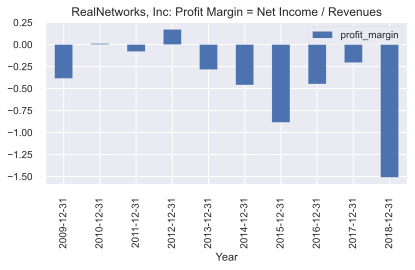

In [315]:
rnwk_profit_margin = ration_analysis(rnwk, 'NetIncomeLoss', 'Revenues',
                                     ratio_name='profit_margin')
sns.set_style('darkgrid')
fig, ax = plt.subplots(1, 1, figsize=(6.5, 3))
rnwk_profit_margin.plot.bar('end', 'profit_margin', ax=ax)
ax.set_xlabel('Year')
ax.set_title("RealNetworks, Inc: Profit Margin = Net Income / Revenues");

Now we will try to calculate average revenue and R&D intensity.

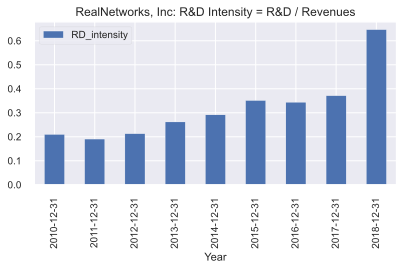

In [316]:
rnwk_rd_intensity = ration_analysis(rnwk, 
                                    'ResearchAndDevelopmentExpense',
                                    'Revenues',
                                    ratio_name='RD_intensity',
                                    average=True)
fig, ax = plt.subplots(1, 1, figsize=(6.5, 3))
rnwk_rd_intensity.plot.bar('end', 'RD_intensity', ax=ax)
ax.set_xlabel('Year');
ax.set_title("RealNetworks, Inc: R&D Intensity = R&D / Revenues");

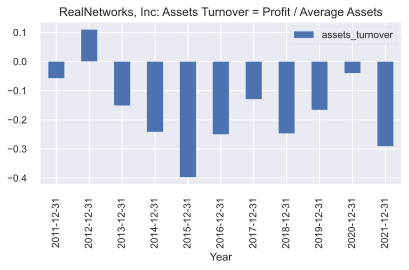

In [319]:
rnwk_asset_turnover = ration_analysis(rnwk,
                                       'NetIncomeLoss',
                                       'Assets',
                                       ratio_name='assets_turnover',
                                       average=True)
fig, ax = plt.subplots(1, 1, figsize=(6.5, 3))
rnwk_asset_turnover.plot.bar('end', 'assets_turnover', ax=ax)
ax.set_xlabel('Year');
ax.set_title("RealNetworks, Inc: Assets Turnover = Profit / Average Assets");

## Some miscellaneous functions

In [ ]:

def _tokenize_accounts(accounts):
    token = []
    temp = ''
    for x in reversed(accounts):
        temp = x + temp
        if x.isupper():
            token.append(temp.lower())
            temp = ''
    return [x for x in reversed(token)]
        
def parse_accounts(firm_gaap):
    accounts_list = []
    for x in firm_gaap.keys():
        accounts_list.append(_tokenize_accounts(x))
    return accounts_list

# example
# rnwk_accounts = rnwk['facts']['us-gaap']
# rnwk_acct_dict = dict(zip(rnwk_accounts.keys(),parse_accounts(rnwk_accounts)))
# for key, value in rnwk_acct_dict.items():
#     if 'profit' in value:
#         print(key, value)